# Lecture 07 – Introducción a Deep Learning
### Universidad EAFIT | 2026 - Introducción a la IA

---

## ¿Qué es Deep Learning?

Las **redes neuronales** son modelos de Machine Learning que aprenden representaciones a partir de datos ajustando parámetros distribuidos en capas interconectadas.

### Deep Learning vs. Machine Learning Tradicional

En el **Machine Learning tradicional**, un experto humano suele diseñar manualmente las features relevantes:

```text
Raw Input → Feature Engineering (humano) → Features → Modelo ML → Output
```

En **Deep Learning**, la red puede aprender automáticamente representaciones útiles a partir de los datos:

```text
Raw Input → DNN (aprende representaciones jerárquicas) → Output
```

> **La clave**: al apilar capas con transformaciones **no lineales**, la red puede aprender representaciones progresivamente más útiles para la tarea.

---

## ¿Qué construiremos en este notebook?

Implementaremos y compararemos **dos modelos con Keras 3** para clasificar imágenes del dataset **Fashion-MNIST**:

| Modelo | Descripción | Frontera de decisión |
|---|---|---|
| **Regresión Logística** | Una sola capa lineal | Lineal |
| **Red Neuronal FC** | Capa oculta + activación ReLU | No lineal |

Fashion-MNIST es más desafiante que MNIST: algunas categorías, como **Shirt**, **T-shirt/top**, **Pullover** y **Coat**, tienen apariencias similares.

Al final podremos observar cómo añadir una capa oculta con una activación no lineal aumenta la capacidad del modelo.

---


## 0. Configuración del entorno

Usaremos **Keras 3**, una API de Deep Learning que permite definir, entrenar y evaluar redes neuronales con una interfaz de alto nivel.

Keras 3 es **multi-backend**: puede trabajar sobre backends compatibles como TensorFlow, JAX o PyTorch. En este notebook utilizaremos exclusivamente la API pública de `keras`.

> A diferencia de PyTorch, en este ejemplo no moveremos manualmente el modelo con `.to(device)`. El backend seleccionado por Keras gestiona la ejecución sobre CPU/GPU según el entorno.


In [1]:
import keras
from keras import layers
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : torch


---
## 1. Carga del Dataset: Fashion-MNIST

**Fashion-MNIST** contiene imágenes de prendas de vestir y calzado:

- **60,000 imágenes** para entrenamiento
- **10,000 imágenes** para prueba
- Cada imagen tiene **28×28 píxeles** en escala de grises
- **10 clases**

| Etiqueta | Clase |
|---:|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

### Representación de una imagen como vector de features

Las imágenes originales contienen intensidades entre 0 y 255. Las normalizamos al rango **[0, 1]**:

$$x_{\text{norm}} = \frac{x}{255}$$

Nuestros modelos fully-connected recibirán cada imagen como un vector de:

$$28\times 28 = 784$$

features.

No es necesario hacer el `reshape` manualmente antes del entrenamiento: añadiremos una capa `Flatten()` dentro del modelo.


In [2]:
# Keras incluye Fashion-MNIST directamente.
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalización: uint8 [0,255] -> float32 [0,1]
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print(f"Muestras de entrenamiento : {len(X_train)}")
print(f"Muestras de prueba        : {len(X_test)}")
print(f"Tamaño de una imagen      : {X_train[0].shape} -> (alto, ancho)")
print(f"Tipo X_train              : {X_train.dtype}")
print(f"Tipo y_train              : {y_train.dtype}")
print(f"Número de clases          : {len(class_names)}")
print(f"Clases                    : {class_names}")


    0/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

16384/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step


       0/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/26421880 ━━━━━━━━━━━━━━━━━━━━ 1:33 4us/step

...

3743744/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4030464/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4268032/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Muestras de entrenamiento : 60000
Muestras de prueba        : 10000
Tamaño de una imagen      : (28, 28) -> (alto, ancho)
Tipo X_train              : float32
Tipo y_train              : uint8
Número de clases          : 10
Clases                    : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### ¿Dónde está el `DataLoader`?

Con Keras podemos entregar directamente arrays de NumPy a `model.fit()`:

```python
model.fit(
    X_train,
    y_train,
    batch_size=64,
    shuffle=True,
)
```

Keras divide los datos internamente en **mini-batches**.

Para este notebook:

| Concepto | PyTorch | Keras 3 |
|---|---|---|
| Dataset | `torchvision.datasets.FashionMNIST` | `keras.datasets.fashion_mnist.load_data()` |
| Mini-batches | `DataLoader(..., batch_size=64)` | `model.fit(..., batch_size=64)` |
| Mezclar ejemplos | `shuffle=True` en `DataLoader` | `shuffle=True` en `fit()` |
| Aplanar imagen | `images.view(-1, 784)` | `layers.Flatten()` |

### ¿Por qué usar mini-batches?

Con un batch de tamaño $B$, el modelo calcula gradientes usando $B$ ejemplos antes de actualizar sus parámetros.

- **Full-batch**: una actualización por epoch.
- **SGD puro**: una actualización por ejemplo.
- **Mini-batch**: compromiso práctico entre eficiencia computacional y ruido del gradiente.

En Fashion-MNIST usaremos:

```python
batch_size = 64
```


In [3]:
batch_size = 64

n_train_batches = int(np.ceil(len(X_train) / batch_size))
n_test_batches  = int(np.ceil(len(X_test) / batch_size))

print(f"Batches de entrenamiento : {n_train_batches}")
print(f"Batches de prueba        : {n_test_batches}")

# Simulamos el primer batch únicamente para explorar sus dimensiones.
images = X_train[:batch_size]
labels = y_train[:batch_size]

print(f"\nShape del batch de imágenes  : {images.shape}")
print(f"Shape del batch de etiquetas : {labels.shape}")
print(f"Etiquetas (primeras 10)      : {labels[:10].tolist()}")
print("Clases (primeras 10)        :", [class_names[label] for label in labels[:10]])


Batches de entrenamiento : 938
Batches de prueba        : 157

Shape del batch de imágenes  : (64, 28, 28)
Shape del batch de etiquetas : (64,)
Etiquetas (primeras 10)      : [9, 0, 0, 3, 0, 2, 7, 2, 5, 5]
Clases (primeras 10)        : ['Ankle boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal']


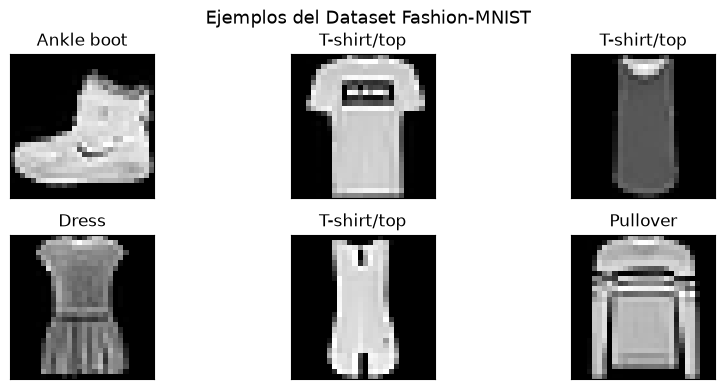

In [4]:
# Visualizamos 6 imágenes de ejemplo.
fig = plt.figure(figsize=(9, 4))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.tight_layout()
    plt.imshow(images[i], cmap="gray", interpolation="none")
    plt.title(class_names[labels[i]])
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Ejemplos del Dataset Fashion-MNIST", fontsize=13, y=1.02)
plt.show()


---
## 2. Definición de modelos

### Revisión: del perceptrón a las redes neuronales

Para clasificación multiclase podemos transformar los **logits** $z_k$ en probabilidades usando Softmax:

$$
P(y_k\mid\mathbf{x})
=
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
$$

La predicción será:

$$
\hat y = \arg\max_k z_k
$$

Aplicar `argmax` sobre logits o sobre probabilidades Softmax produce la misma clase.

### Modelo 1 — Regresión logística

Arquitectura:

```text
Input(28×28) → Flatten(784) → Dense(10) → logits
```

Es un modelo **lineal** respecto a las 784 features de píxel.

### Modelo 2 — Red neuronal fully-connected

Arquitectura:

```text
Input(28×28) → Flatten(784) → Dense(128) → ReLU → Dense(10) → logits
```

La activación ReLU:

$$
g(x)=\max(0,x)
$$

introduce **no linealidad**. Sin una activación no lineal entre capas, varias capas `Dense` consecutivas seguirían representando una única transformación lineal.

En Fashion-MNIST esta mayor capacidad es especialmente útil porque varias categorías de ropa son visualmente parecidas.


In [5]:
input_shape = (28, 28)
output_dim  = 10

# =============================================================================
# MODELO 1: Regresión Logística
# Input(28,28) -> Flatten(784) -> Dense(10)
# =============================================================================
logistic_model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Flatten(name="flatten"),
        layers.Dense(output_dim, name="logits"),
    ],
    name="LogisticRegression",
)

# =============================================================================
# MODELO 2: Red Fully-Connected
# Input(28,28) -> Flatten(784) -> Dense(128) -> ReLU -> Dense(10)
# =============================================================================
fc_model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Flatten(name="flatten"),
        layers.Dense(128, activation="relu", name="hidden"),
        layers.Dense(output_dim, name="logits"),
    ],
    name="FCNeuralNetwork",
)

print("Modelos definidos exitosamente.\n")
print("LogisticRegression : 784 -> Dense(10)")
print("FCNeuralNetwork    : 784 -> Dense(128) -> ReLU -> Dense(10)")


Modelos definidos exitosamente.

LogisticRegression : 784 -> Dense(10)
FCNeuralNetwork    : 784 -> Dense(128) -> ReLU -> Dense(10)


In [6]:
print("=== Regresión Logística ===")
logistic_model.summary()

print("\n=== Red Neuronal FC ===")
fc_model.summary()

print(f"\nParámetros LogisticRegression : {logistic_model.count_params():,}")
print(f"Parámetros FCNeuralNetwork    : {fc_model.count_params():,}")


=== Regresión Logística ===


Model: "LogisticRegression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Parámetros LogisticRegression : 7,850
Parámetros FCNeuralNetwork    : 101,770


---
## 3. Configuración del entrenamiento

### Hiperparámetros

- **`epochs = 10`**: número de pasadas completas por los datos.
- **`batch_size = 64`**: ejemplos usados por actualización.
- **`lr_rate = 0.001`**: learning rate de Adam.

### Función de pérdida: Sparse Categorical Cross-Entropy

Las etiquetas de Fashion-MNIST están almacenadas como enteros entre 0 y 9. Cada entero identifica una categoría de prenda.

Por eso usaremos:

```python
keras.losses.SparseCategoricalCrossentropy(from_logits=True)
```

`from_logits=True` es importante porque la última capa produce **logits**, no probabilidades.

Conceptualmente, la pérdida incorpora la transformación Softmax necesaria para calcular la cross-entropy de forma numéricamente estable. Por eso **no añadimos `Softmax` a la última capa**.

### Optimizador: Adam

Usaremos:

```python
keras.optimizers.Adam(learning_rate=0.001)
```

Keras conectará el optimizador, la función de pérdida y las métricas mediante `model.compile()`.


In [7]:
epochs  = 10
lr_rate = 0.001

loss_fn = keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

def compile_model(model):
    # Creamos un optimizador nuevo para cada modelo.
    optimizer = keras.optimizers.Adam(learning_rate=lr_rate)

    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ],
    )

print(f"Épocas de entrenamiento : {epochs}")
print(f"Batch size              : {batch_size}")
print(f"Learning rate           : {lr_rate}")
print("Loss                    : SparseCategoricalCrossentropy(from_logits=True)")
print("Optimizer               : Adam")


Épocas de entrenamiento : 10
Batch size              : 64
Learning rate           : 0.001
Loss                    : SparseCategoricalCrossentropy(from_logits=True)
Optimizer               : Adam


### Elegimos el modelo

Cambia únicamente esta variable para repetir el experimento:

```python
MODEL_TYPE = "logistic"
```

o:

```python
MODEL_TYPE = "fc"
```


In [8]:
MODEL_TYPE = "logistic"   # "logistic" o "fc"

if MODEL_TYPE == "logistic":
    model = logistic_model
elif MODEL_TYPE == "fc":
    model = fc_model
else:
    raise ValueError("MODEL_TYPE debe ser 'logistic' o 'fc'")

compile_model(model)

print(f"Modelo seleccionado: {model.name}")
print(f"Parámetros entrenables: {model.count_params():,}")


Modelo seleccionado: LogisticRegression
Parámetros entrenables: 7,850


---
## 4. Ciclo de entrenamiento

En una implementación de bajo nivel, cada mini-batch requiere conceptualmente:

```text
1. Forward pass
2. Calcular loss
3. Calcular gradientes con backpropagation
4. Actualizar parámetros con el optimizador
```

Con Keras 3, `model.fit()` ejecuta este ciclo automáticamente:

```python
history = model.fit(...)
```

La correspondencia conceptual es:

| Concepto | Implementación manual | Keras 3 |
|---|---|---|
| Forward | `outputs = model(x)` | interno en `fit()` |
| Loss | `loss_fn(y, outputs)` | definido en `compile()` |
| Backpropagation | autodiferenciación | interno en `fit()` |
| Actualización | `optimizer.step/apply...` | interno en `fit()` |
| Mini-batches | loop explícito | `batch_size=64` |
| Epochs | loop externo | `epochs=10` |

### Backpropagation

Backpropagation usa la regla de la cadena para calcular:

$$
\frac{\partial\mathcal L}{\partial W^{(k)}}
=
\frac{\partial\mathcal L}{\partial z^{(k)}}
\frac{\partial z^{(k)}}{\partial W^{(k)}}
$$

Keras delega el cálculo automático de esos gradientes al backend seleccionado.


In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    verbose=1,
)


Epoch 1/10


  1/938 ━━━━━━━━━━━━━━━━━━━━ 1:11 77ms/step - accuracy: 0.2656 - loss: 2.2155

  7/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2634 - loss: 2.0992   

 14/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3259 - loss: 1.9575

 20/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3984 - loss: 1.8036

...

914/938 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8630 - loss: 0.3967

921/938 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8627 - loss: 0.3971

927/938 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8629 - loss: 0.3969

934/938 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8630 - loss: 0.3967

938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8629 - loss: 0.3968 - val_accuracy: 0.8433 - val_loss: 0.4459


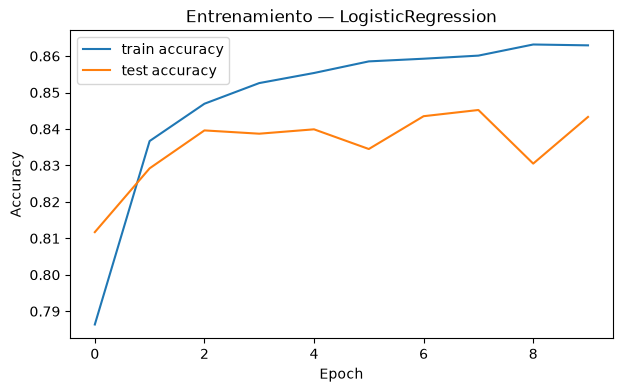

In [10]:
# Graficamos la evolución del entrenamiento.
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Entrenamiento — {model.name}")
plt.legend()
plt.show()


### Logits vs. probabilidades

La última capa:

```python
layers.Dense(10)
```

no tiene activación. Por lo tanto produce **logits**.

Para interpretar esos valores como probabilidades usamos Softmax:

$$
P(y_k\mid x)
=
\frac{e^{z_k}}
{\sum_j e^{z_j}}
$$

Durante el entrenamiento no necesitamos añadir Softmax al modelo porque la loss fue configurada con `from_logits=True`.


In [11]:
# Tomamos una imagen de prueba.
sample = X_test[:1]
true_label = y_test[0]

# Forward pass directo: devuelve logits.
logits = model(sample, training=False)[0]

print("Logits:")
print(keras.ops.convert_to_numpy(logits))
print(
    f"\nSuma de logits: "
    f"{float(keras.ops.convert_to_numpy(keras.ops.sum(logits))):.4f} "
    "← NO tiene que ser 1"
)

# Convertimos logits a probabilidades.
probs = keras.ops.softmax(logits)
probs_np = keras.ops.convert_to_numpy(probs)

pred_class = int(np.argmax(probs_np))

print("\nProbabilidades (Softmax):")
for k, p in enumerate(probs_np):
    marker = " <- PREDICCIÓN" if k == pred_class else ""
    print(f"  {k}: {class_names[k]:12s} -> {p:.4f}{marker}")

print(f"\nSuma de probabilidades: {probs_np.sum():.6f}")
print(f"Clase real             : {true_label} -> {class_names[true_label]}")
print(f"Clase predicha         : {pred_class} -> {class_names[pred_class]}")


Logits:
[-7.418963  -9.511391  -4.320578  -5.474219  -4.76872    4.702005
 -3.5339065  4.370009   1.5413375  6.6435876]

Suma de logits: -17.7708 ← NO tiene que ser 1

Probabilidades (Softmax):
  0: T-shirt/top  -> 0.0000
  1: Trouser      -> 0.0000
  2: Pullover     -> 0.0000
  3: Dress        -> 0.0000
  4: Coat         -> 0.0000
  5: Sandal       -> 0.1145
  6: Shirt        -> 0.0000
  7: Sneaker      -> 0.0822
  8: Bag          -> 0.0049
  9: Ankle boot   -> 0.7984 <- PREDICCIÓN

Suma de probabilidades: 1.000000
Clase real             : 9 -> Ankle boot
Clase predicha         : 9 -> Ankle boot


---
## 5. Evaluación del modelo

Una vez entrenado, evaluamos sobre las **10,000 imágenes de prueba**, que no se usan para actualizar los parámetros.

Con Keras:

```python
model.evaluate(X_test, y_test)
```

Durante `evaluate()` el modelo trabaja en modo inferencia automáticamente.

### Overfitting y generalización

Si el desempeño en entrenamiento aumenta mientras que el desempeño en prueba deja de mejorar o empeora, existe evidencia de **overfitting**.

Fashion-MNIST es más difícil que MNIST porque algunas categorías comparten patrones visuales similares, especialmente `T-shirt/top`, `Shirt`, `Pullover` y `Coat`.

Algunas estrategias comunes para mitigarlo son:

- Early Stopping
- Dropout
- Regularización L2
- Data augmentation
- Reducir la complejidad del modelo


In [12]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0,
)

print(f"Loss en prueba     : {test_loss:.4f}")
print(f"Accuracy en prueba : {test_accuracy:.4f}")
print(
    f"→ {test_accuracy * 100:.2f}% de las "
    f"{len(X_test)} imágenes clasificadas correctamente"
)


Loss en prueba     : 0.4459
Accuracy en prueba : 0.8433
→ 84.33% de las 10000 imágenes clasificadas correctamente


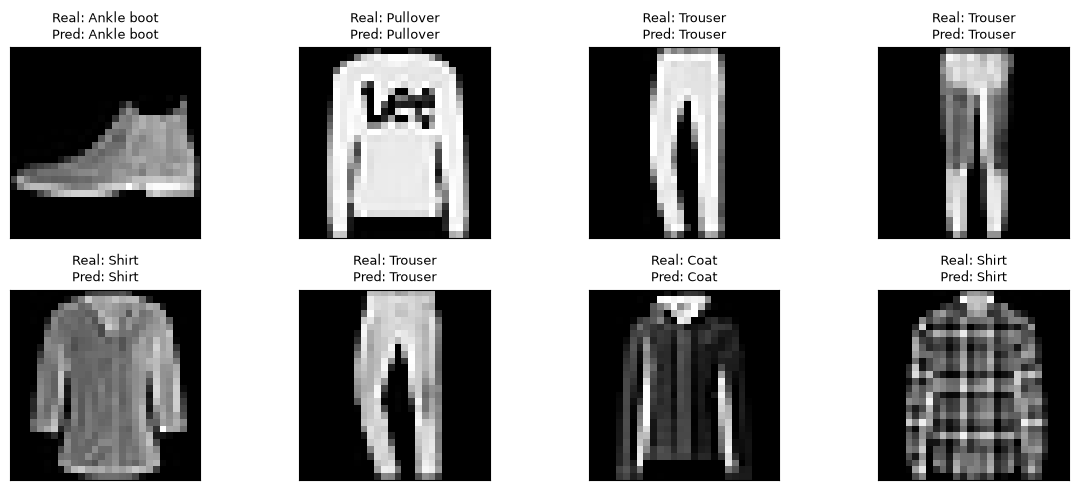

In [13]:
# Visualizamos algunas predicciones.
n = 8
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.convert_to_numpy(
    keras.ops.argmax(logits_batch, axis=1)
)

fig = plt.figure(figsize=(12, 5))

for i in range(n):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(
        f"Real: {class_names[y_test[i]]}\n"
        f"Pred: {class_names[predictions[i]]}",
        fontsize=9,
    )
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
## 6. Conclusiones y próximos pasos

### Resultados esperados

Los valores exactos dependen de la inicialización y del entrenamiento, pero normalmente veremos una diferencia clara entre ambos modelos:

| Modelo | Accuracy en prueba (aprox.) | Parámetros |
|---|---:|---:|
| Regresión Logística | ~83–85% | 7,850 |
| **FC Neural Network** (784→128→10) | **~87–89%** | 101,770 |

La red neuronal FC tiene mayor capacidad que la regresión logística porque la combinación:

```text
Dense(128) → ReLU
```

introduce una transformación no lineal del espacio de entrada.

Fashion-MNIST permite ver mejor esta diferencia que MNIST porque varias clases son visualmente similares y no pueden separarse tan fácilmente mediante una transformación lineal.

### Conceptos que vimos

```text
Datos
  ↓
mini-batches
  ↓
Forward pass
  ↓
Logits
  ↓
Cross-Entropy Loss
  ↓
Backpropagation
  ↓
Adam
  ↓
Actualización de parámetros
```

Keras 3 encapsula este ciclo con:

```python
model.compile(...)
model.fit(...)
model.evaluate(...)
```

pero los conceptos matemáticos subyacentes siguen siendo los mismos.

### Experimentos sugeridos

- Cambia `MODEL_TYPE = "fc"` y compara con la regresión logística.
- Identifica cuáles clases se confunden más.
- Añade una segunda capa oculta.
- Cambia `relu` por `tanh` o `sigmoid`.
- Cambia `batch_size`.
- Prueba distintos valores de `lr_rate`.
- Aumenta o reduce el número de epochs.
- Añade `Dropout`.
- Compara train accuracy y test accuracy.
- Como siguiente paso, compara esta red fully-connected con una **CNN**, que aprovecha explícitamente la estructura espacial de las imágenes.

---

### Equivalencias principales: PyTorch → Keras 3

| PyTorch | Keras 3 |
|---|---|
| `torchvision.datasets.FashionMNIST` | `keras.datasets.fashion_mnist.load_data()` |
| `DataLoader` | `model.fit(..., batch_size=...)` |
| `torch.nn.Linear` | `layers.Dense` |
| `torch.nn.functional.relu` | `activation="relu"` |
| `CrossEntropyLoss` | `SparseCategoricalCrossentropy(from_logits=True)` |
| `torch.optim.Adam` | `keras.optimizers.Adam` |
| `loss.backward()` | autodiferenciación interna durante `fit()` |
| `optimizer.step()` | actualización interna durante `fit()` |
| `torch.argmax` | `keras.ops.argmax` |
| `torch.nn.functional.softmax` | `keras.ops.softmax` |
| `model.eval()` + `no_grad()` | `model.evaluate()` o `model(..., training=False)` |
